### 傳統 ML 模型訓練與比較

In [16]:
import pandas as pd
import numpy as np
df = pd.read_csv('../data/cleaned_encoded_data.csv')
df.head(5)
df.isna().sum()

gender                      0
no_show                     0
appointment_shift           0
age                      8691
under_12_years_old          0
                         ... 
appointment_year_2018       0
appointment_year_2019       0
appointment_year_2020       0
appointment_year_2021       0
appointment_year_2022       0
Length: 74, dtype: int64

In [17]:
# Split Features and Target
X = df.drop(columns=['no_show'])
y = df['no_show']


In [18]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) # Stratify to maintain the distribution of the target variable in both train and test sets


### Model Training 
#### 1. Logistic Regression
#### 2. Decision Tree
#### 3. Random Forest 

In [19]:
### Start with Basic Logistic Regression Model 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [20]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
### Add Imputer and Missing indicators for missing values
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler

# 首先創建缺失值指示器
missing_indicator = X_train['age'].isna().astype(int).values.reshape(-1, 1)
missing_indicator_test = X_test['age'].isna().astype(int).values.reshape(-1, 1)

# 創建和使用 imputer
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 特徵縮放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 將缺失值指示器與縮放後的特徵組合
X_train_final = np.hstack((missing_indicator, X_train_scaled))
X_test_final = np.hstack((missing_indicator_test, X_test_scaled))



In [24]:
# Fix Imbalance data using SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)

print("After SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
no_show
0    33579
1     3728
Name: count, dtype: int64
After SMOTE:
no_show
0    33579
1    33579
Name: count, dtype: int64


In [26]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_balanced, y_train_balanced)

LogisticRegression(max_iter=1000, random_state=42)

In [28]:
y_pred = logreg.predict(X_test_final)
y_pred_proba = logreg.predict_proba(X_test_final)[:, 1]

#### Evaluation Metrics:
1. Accuracy = (TP + TN) / (TP + FP + TN + FN) 
2. Precision = TP / (TP + FN) 
3. Recall = TP / (TP + EN) -> 成功預測出來的比例
4. F1 Score = 2 * (Precision + Recall) / (Precision + Recall) 
5. ROC AUC

In [35]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(y_test, y_pred, y_pred_proba, model_name="Model"):
    # Calculate all metrics at once
    print(f"{model_name} Evaluation:")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")
    print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba):.3f}\n")
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Show', 'Show'], 
                yticklabels=['No Show', 'Show'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print(classification_report(y_test, y_pred))

Logistic Regression Evaluation:
Precision: 0.145
Recall:    0.609
F1 Score:  0.234
ROC AUC:   0.640



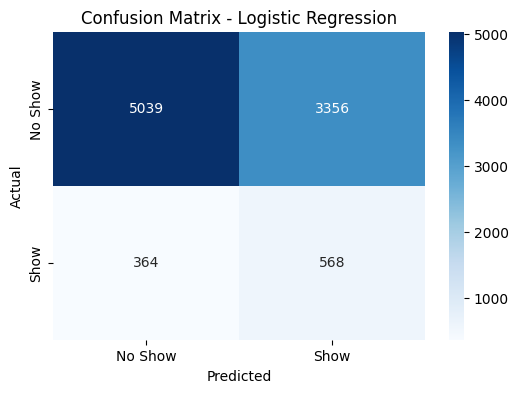

              precision    recall  f1-score   support

           0       0.93      0.60      0.73      8395
           1       0.14      0.61      0.23       932

    accuracy                           0.60      9327
   macro avg       0.54      0.60      0.48      9327
weighted avg       0.85      0.60      0.68      9327



In [36]:
evaluate_model(y_test, y_pred, y_pred_proba, "Logistic Regression")

### The performance of simple Logistric Regression is bad based on:
1. Low Precision 0.2 -> Of all predicted "no-shows", only 20% were truly no-shows
2. Low Recall 0.034 -> Model found only 3.4% of all actual no-shows
3. Low F1 Score  0.058 -> Balance between precision & recall — quite low
4. Low ROC AUC: 0.585 -> Barely better than random guessing (0.5 is random)

### Try Random Forest 

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # allow trees to grow fully
    random_state=42,
    class_weight=None        # SMOTE already handled imbalance
)

rf_model.fit(X_train_balanced, y_train_balanced)


RandomForestClassifier(random_state=42)

In [38]:
y_pred_rf = rf_model.predict(X_test_final)
y_proba_rf = rf_model.predict_proba(X_test_final)[:, 1]  # needed for AUC

Random Forest Evaluation:
Precision: 0.346
Recall:    0.117
F1 Score:  0.175
ROC AUC:   0.742



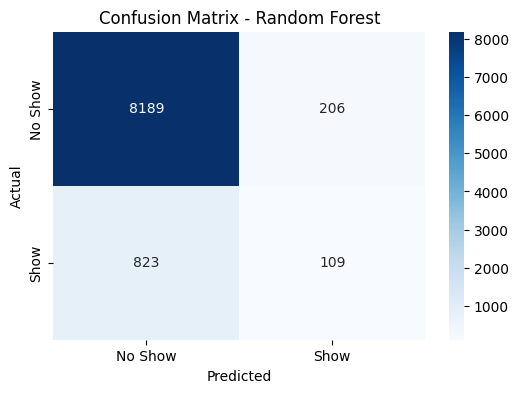

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      8395
           1       0.35      0.12      0.17       932

    accuracy                           0.89      9327
   macro avg       0.63      0.55      0.56      9327
weighted avg       0.85      0.89      0.86      9327



In [39]:
evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")


In [42]:
rf_model_2 = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=None,          # allow trees to grow fully
    random_state=42,
    class_weight='balanced',        
    min_samples_split=2
)

rf_model_2.fit(X_train, y_train)
y_pred_rf = rf_model_2.predict(X_test)
y_proba_rf = rf_model_2.predict_proba(X_test)[:, 1]  # needed for AUC

Random Forest_Weighted Evaluation:
Precision: 0.375
Recall:    0.113
F1 Score:  0.173
ROC AUC:   0.773



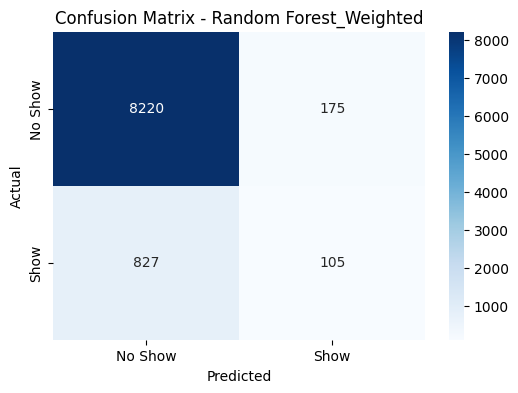

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      8395
           1       0.38      0.11      0.17       932

    accuracy                           0.89      9327
   macro avg       0.64      0.55      0.56      9327
weighted avg       0.86      0.89      0.87      9327



In [43]:
evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest_Weighted")

In [45]:
threshold = 0.25
y_pred_custom = (y_proba_rf >= threshold).astype(int)
# Re-evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.93      0.92      0.93      8395
           1       0.34      0.35      0.34       932

    accuracy                           0.87      9327
   macro avg       0.63      0.64      0.63      9327
weighted avg       0.87      0.87      0.87      9327



## Why Class Weights Worked Better
1. SMOTE creates synthetic examples that may not generalize well

2. Random Forest already does internal bootstrapping + averaging

3. Giving the model correct penalties via class weights is more elegant and stable



In [46]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],         # number of trees
    'max_depth': [10, 20, None],        # how deep each tree can grow
    'min_samples_split': [2, 5],        # min samples to split a node
    'max_features': ['sqrt', 'log2']    # features per split
}
grid = GridSearchCV(rf_model, 
              param_grid,
              scoring='recall',
              cv=5, 
              n_jobs=-1, 
              verbose=2
              )

In [47]:
grid.fit(X_train_balanced, y_train_balanced)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   8.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   4.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   4.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   9.2s
[CV] END max_depth=10, max_features=sq

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='recall', verbose=2)

Best parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}
Random Forest_Best Evaluation:
Precision: 0.352
Recall:    0.115
F1 Score:  0.173
ROC AUC:   0.742



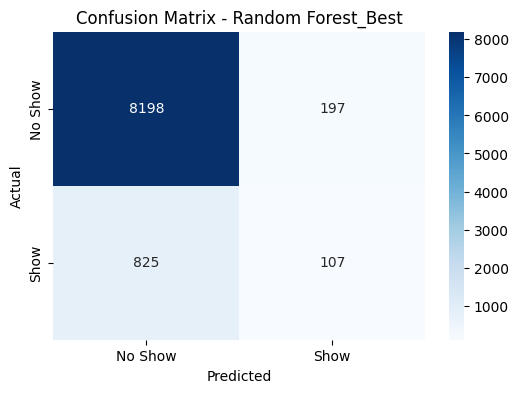

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      8395
           1       0.35      0.11      0.17       932

    accuracy                           0.89      9327
   macro avg       0.63      0.55      0.56      9327
weighted avg       0.85      0.89      0.86      9327



In [50]:
best_rf = grid.best_estimator_

print("Best parameters:", grid.best_params_)

# Predict on test set
y_pred_best = best_rf.predict(X_test_final)
y_proba_best = best_rf.predict_proba(X_test_final)[:, 1]

# Evaluate
evaluate_model(y_test, y_pred_best, y_proba_best, "Random Forest_Best")


In [52]:
# Predict probabilities
y_proba = best_rf.predict_proba(X_test_final)[:, 1]

# Set a custom threshold (e.g., 0.3 instead of 0.5)
threshold = 0.30
y_pred_custom = (y_proba >= threshold).astype(int)

# Re-evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      8395
           1       0.29      0.29      0.29       932

    accuracy                           0.86      9327
   macro avg       0.61      0.61      0.61      9327
weighted avg       0.86      0.86      0.86      9327



### XGBoost

In [53]:
import xgboost as xgb

In [54]:
# Compute ratio: (negative class / positive class)
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", ratio)


scale_pos_weight: 9.007242489270386


In [55]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=ratio,    
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)


/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:10:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

XGBoost Evaluation:
Precision: 0.200
Recall:    0.595
F1 Score:  0.299
ROC AUC:   0.735



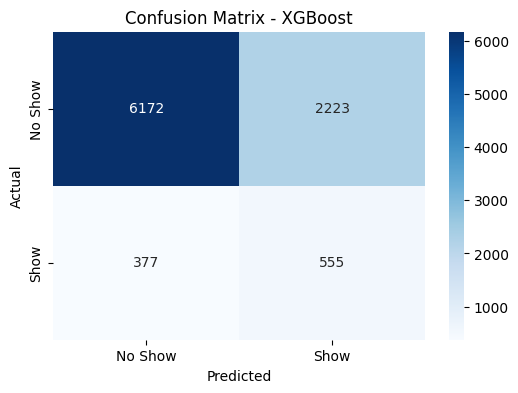

              precision    recall  f1-score   support

           0       0.94      0.74      0.83      8395
           1       0.20      0.60      0.30       932

    accuracy                           0.72      9327
   macro avg       0.57      0.67      0.56      9327
weighted avg       0.87      0.72      0.77      9327



In [59]:
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_proba, "XGBoost")


In [60]:
threshold = 0.35
y_pred_custom = (y_proba >= threshold).astype(int)
print("Custom Threshold Report:")
print(classification_report(y_test, y_pred_custom))


Custom Threshold Report:
              precision    recall  f1-score   support

           0       0.97      0.44      0.61      8395
           1       0.15      0.86      0.25       932

    accuracy                           0.48      9327
   macro avg       0.56      0.65      0.43      9327
weighted avg       0.88      0.48      0.57      9327



## For Shows (Class 0):
1. Precision: 0.97 → 97% of patients predicted to show up actually showed up (improved)
2. Recall: 0.44 → Only 44% of actual show-ups were correctly identified (decreased)
3. F1-score: 0.61 → Moderate balanced performance for show-ups

## For No-shows (Class 1):
1. Precision: 0.15 → Only 15% of patients predicted to no-show actually didn't show up
2. Recall: 0.86 → 86% of actual no-shows were correctly identified (significantly improved)
3. F1-score: 0.25 → Still weak overall performance, but better at catching no-shows

In [79]:
## Fine Tuning XGBoost Model
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],              # Add to prevent overfitting
    'gamma': [0, 0.1, 0.2],                     # Minimum loss reduction
    'reg_alpha': [0, 0.1, 1.0],                 # L1 regularization
    'reg_lambda': [0, 1.0, 5.0]                 # L2 regularization
}

xgb_clf = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='recall',         # optimize for recall!
    cv=3,
    n_jobs=-1,
    verbose=2
)



In [ ]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 19683 candidates, totalling 59049 fits


Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
XGBoost_Best Evaluation:
Precision: 0.246
Recall:    0.524
F1 Score:  0.335
ROC AUC:   0.759



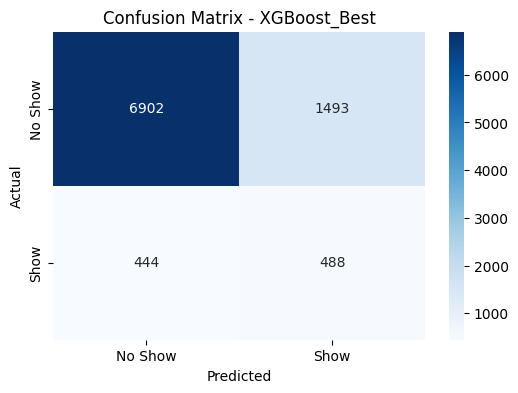

              precision    recall  f1-score   support

           0       0.94      0.82      0.88      8395
           1       0.25      0.52      0.34       932

    accuracy                           0.79      9327
   macro avg       0.59      0.67      0.61      9327
weighted avg       0.87      0.79      0.82      9327



In [71]:
best_xgb = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)

# Predict and evaluate
y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_best, y_proba_best, "XGBoost_Best")


In [ ]:
threshold = 0.35
y_pred_thresholded = (y_proba_best >= threshold).astype(int)

print("Threshold-Tuned Report:")
print(classification_report(y_test, y_pred_thresholded))


Threshold-Tuned Report:
              precision    recall  f1-score   support

           0       0.96      0.65      0.78      8395
           1       0.19      0.75      0.31       932

    accuracy                           0.66      9327
   macro avg       0.58      0.70      0.54      9327
weighted avg       0.88      0.66      0.73      9327



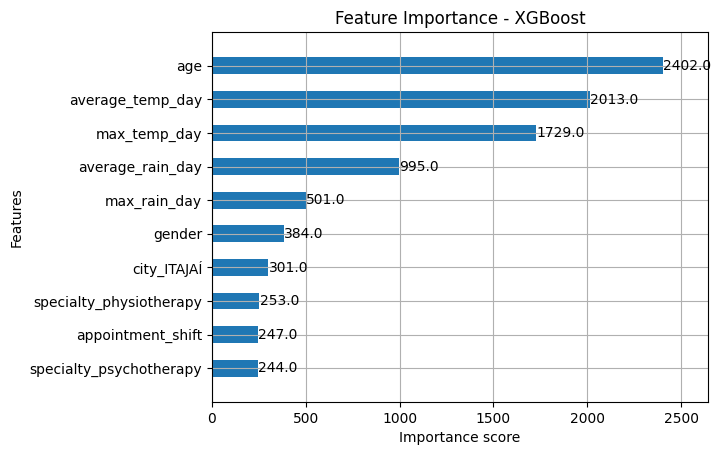

In [74]:
## Feature Importance
import matplotlib.pyplot as plt
xgb.plot_importance(best_xgb, max_num_features=10, importance_type='weight', height=0.5)
plt.title('Feature Importance - XGBoost')
plt.show()

In [50]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),    # Required for NN
    ('mlp', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42))
])

pipeline.fit(X_train_balanced, y_train_balanced)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]


/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [51]:
from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.91      0.93      0.92     12593
           1       0.22      0.19      0.20      1398

    accuracy                           0.85     13991
   macro avg       0.56      0.56      0.56     13991
weighted avg       0.84      0.85      0.85     13991

AUC: 0.6448403278747747


In [52]:
### 